# 🌿 AgriAI — Crop Disease Classification
**Model:** ResNet50 Transfer Learning  
**Dataset:** PlantVillage — already extracted under `/kaggle/input/Plant_Dataset/`  
**Platform:** Kaggle (GPU T4 / P100)

---
**Before running:** Settings → Accelerator → GPU T4 → Run All

## 1 — Imports & Device

In [1]:
import os, sys, random, json, pickle, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow.')
    print('Go to Settings → Accelerator → GPU T4')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2 — Locate Dataset (Already Extracted)

In [3]:
# ── Dataset is already extracted — no zip needed ──────────────
# Structure seen in Kaggle sidebar:
#   /kaggle/input/Plant_Dataset/plantville dataset/color/<38 classes>/

# Try known paths in order
CANDIDATES = [
    '/kaggle/input/Plant_Dataset/plantville dataset/color',
    '/kaggle/input/Plant_Dataset/plantvillage dataset/color',
    '/kaggle/input/plant-dataset/plantville dataset/color',
    '/kaggle/input/plant-dataset/plantvillage dataset/color',
]

DATA_DIR = None
for c in CANDIDATES:
    p = Path(c)
    if p.exists() and len(list(p.iterdir())) >= 10:
        DATA_DIR = p
        print(f'Found dataset at: {DATA_DIR}')
        break

# Fallback: search all of /kaggle/input for a folder
# that contains 30+ sub-directories (class folders)
if DATA_DIR is None:
    print('Known paths not found — scanning /kaggle/input ...')
    for root, dirs, files in os.walk('/kaggle/input'):
        subdirs = [d for d in Path(root).iterdir() if d.is_dir()]
        if len(subdirs) >= 30:
            DATA_DIR = Path(root)
            print(f'Auto-found dataset at: {DATA_DIR}')
            break

if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find the color/ folder.\n'
        'Print os.walk results and set DATA_DIR manually.'
    )

# ── Confirm classes ───────────────────────────────────────────
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f'Classes found : {len(class_dirs)}')
print('\nAll classes:')
for d in class_dirs:
    n = len(list(d.rglob('*.jpg'))) + len(list(d.rglob('*.JPG'))) + len(list(d.rglob('*.png')))
    print(f'  {d.name:50s}  {n:5d} images')

Known paths not found — scanning /kaggle/input ...
Auto-found dataset at: /kaggle/input/datasets/ankitroy16/plant-dataset/plantvillage dataset/segmented
Classes found : 38

All classes:
  Apple___Apple_scab                                    630 images
  Apple___Black_rot                                     621 images
  Apple___Cedar_apple_rust                              275 images
  Apple___healthy                                      1645 images
  Blueberry___healthy                                  1502 images
  Cherry_(including_sour)___Powdery_mildew             1052 images
  Cherry_(including_sour)___healthy                     854 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    513 images
  Corn_(maize)___Common_rust_                          1192 images
  Corn_(maize)___Northern_Leaf_Blight                   985 images
  Corn_(maize)___healthy                               1162 images
  Grape___Black_rot                                    1180 images
  Grape___

## 3 — Transforms & DataLoaders

In [5]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Load & split ──────────────────────────────────────────────
full_ds     = datasets.ImageFolder(root=str(DATA_DIR), transform=train_tf)
NUM_CLASSES = len(full_ds.classes)
CLASS_NAMES = full_ds.classes
N_TOTAL     = len(full_ds)

n_train = int(0.80 * N_TOTAL)
n_val   = int(0.10 * N_TOTAL)
n_test  = N_TOTAL - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Val and test get no augmentation
val_ds_clean  = datasets.ImageFolder(str(DATA_DIR), transform=val_tf)
test_ds_clean = datasets.ImageFolder(str(DATA_DIR), transform=val_tf)

from torch.utils.data import Subset
val_ds  = Subset(val_ds_clean,  val_ds.indices)
test_ds = Subset(test_ds_clean, test_ds.indices)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Total   : {N_TOTAL:,} images  |  {NUM_CLASSES} classes')
print(f'Train   : {n_train:,}')
print(f'Val     : {n_val:,}')
print(f'Test    : {n_test:,}')

Total   : 54,306 images  |  38 classes
Train   : 43,444
Val     : 5,430
Test    : 5,432


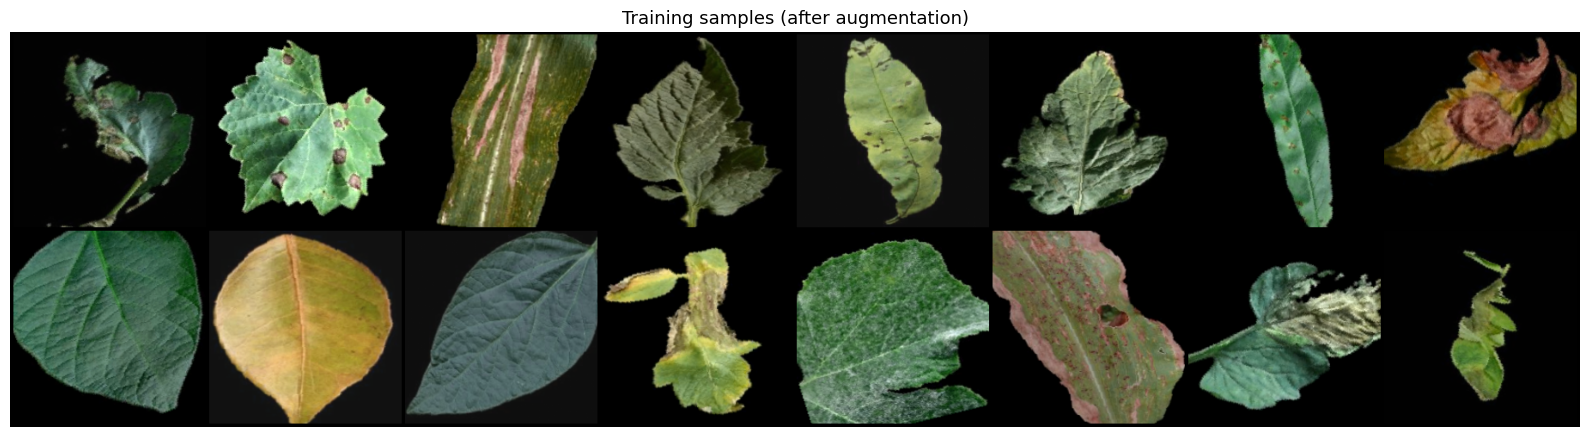

In [6]:
# ── Visualise sample batch ────────────────────────────────────
def denorm(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return torch.clamp(t * s + m, 0, 1)

imgs, lbls = next(iter(train_loader))
grid = make_grid(denorm(imgs[:16]), nrow=8, padding=4)
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(grid.permute(1, 2, 0))
ax.axis('off')
ax.set_title('Training samples (after augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

## 4 — ResNet50 Model

In [10]:
def build_resnet50(num_classes: int) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in model.parameters():
        p.requires_grad = False
    # Unfreeze layer4 + 3— fine-tune high-level features
    for p in model.layer3.parameters():
        p.requires_grad = True
    for p in model.layer4.parameters():
        p.requires_grad = True
    # Custom classification head
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_feat, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

model     = build_resnet50(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'Trainable : {trainable:,} / {total_p:,} ({trainable/total_p:.1%})')

Trainable : 23,132,710 / 24,577,638 (94.1%)


## 5 — Training

In [11]:
EPOCHS     = 15
EARLY_STOP = 5
CKPT_PATH  = '/kaggle/working/best_disease_model.pt'

history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}
best_val_acc = 0.0
patience_ctr = 0


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


print(f'  Epoch   Train Loss   Train Acc    Val Loss    Val Acc      LR')
print(f'  ───────────────────────────────────────────────────────────────')

for epoch in range(1, EPOCHS + 1):
    tr_l, tr_a = run_epoch(train_loader, train=True)
    vl_l, vl_a = run_epoch(val_loader,   train=False)
    scheduler.step(vl_l)

    history['train_loss'].append(tr_l)
    history['train_acc'].append(tr_a)
    history['val_loss'].append(vl_l)
    history['val_acc'].append(vl_a)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'  {epoch:>5}   {tr_l:>10.4f}   {tr_a:>8.2%}   '
          f'{vl_l:>9.4f}   {vl_a:>7.2%}   {lr_now:.2e}')

    if vl_a > best_val_acc:
        best_val_acc = vl_a
        torch.save({
            'epoch':             epoch,
            'model_state_dict':  model.state_dict(),
            'class_names':       CLASS_NAMES,
            'num_classes':       NUM_CLASSES,
            'img_size':          IMG_SIZE,
            'mean':              MEAN,
            'std':               STD,
            'val_accuracy':      best_val_acc,
        }, CKPT_PATH)
        patience_ctr = 0
        print(f'         ✓ Saved checkpoint  (val_acc={best_val_acc:.2%})')
    else:
        patience_ctr += 1
        if patience_ctr >= EARLY_STOP:
            print(f'\n  Early stopping at epoch {epoch}.')
            break

print(f'\nBest validation accuracy: {best_val_acc:.2%}')

  Epoch   Train Loss   Train Acc    Val Loss    Val Acc      LR
  ───────────────────────────────────────────────────────────────
      1       0.9792     91.10%      0.7941    95.80%   3.00e-04
         ✓ Saved checkpoint  (val_acc=95.80%)
      2       0.8113     96.47%      0.7704    97.31%   3.00e-04
         ✓ Saved checkpoint  (val_acc=97.31%)
      3       0.7946     97.00%      0.7518    98.12%   3.00e-04
         ✓ Saved checkpoint  (val_acc=98.12%)
      4       0.7818     97.45%      0.7740    96.78%   3.00e-04
      5       0.7743     97.74%      0.7368    98.27%   3.00e-04
         ✓ Saved checkpoint  (val_acc=98.27%)
      6       0.7714     97.67%      0.7341    98.51%   3.00e-04
         ✓ Saved checkpoint  (val_acc=98.51%)
      7       0.7647     97.89%      0.7484    97.88%   3.00e-04
      8       0.7611     97.95%      0.7262    98.71%   3.00e-04
         ✓ Saved checkpoint  (val_acc=98.71%)
      9       0.7579     98.07%      0.7337    98.38%   3.00e-04
     10  

## 6 — Evaluation

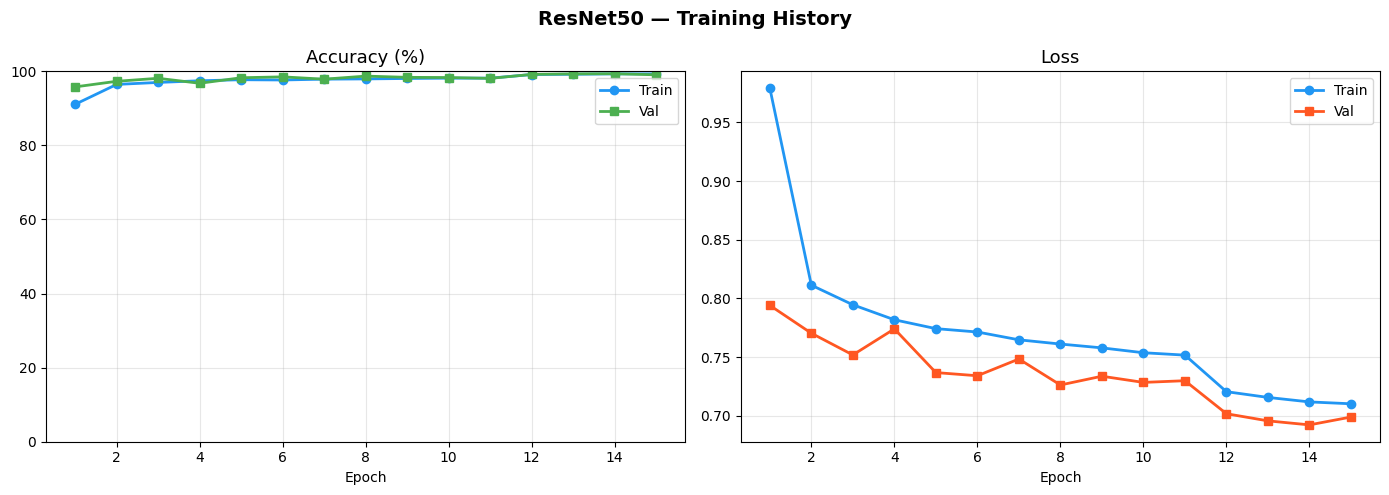

In [12]:
ep = range(1, len(history['train_acc']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, [a*100 for a in history['train_acc']], 'o-', label='Train', color='#2196F3', lw=2)
ax1.plot(ep, [a*100 for a in history['val_acc']],   's-', label='Val',   color='#4CAF50', lw=2)
ax1.set_title('Accuracy (%)', fontsize=13); ax1.set_ylim(0,100)
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_loss'], 'o-', label='Train', color='#2196F3', lw=2)
ax2.plot(ep, history['val_loss'],   's-', label='Val',   color='#FF5722', lw=2)
ax2.set_title('Loss', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('ResNet50 — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [13]:
# ── Test set accuracy ─────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()

print(f'Test Accuracy : {test_acc:.2%}')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES, digits=3
))

Test Accuracy : 99.34%

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      1.000     1.000     1.000        59
                                 Apple___Black_rot      1.000     1.000     1.000        66
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        30
                                   Apple___healthy      1.000     1.000     1.000       166
                               Blueberry___healthy      1.000     1.000     1.000       150
          Cherry_(including_sour)___Powdery_mildew      1.000     0.991     0.996       113
                 Cherry_(including_sour)___healthy      1.000     1.000     1.000        93
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.843     0.977     0.905        44
                       Corn_(maize)___Common_rust_      1.000     1.000     1.000       133
               Corn_(maize)___Northern_Leaf_Blight     

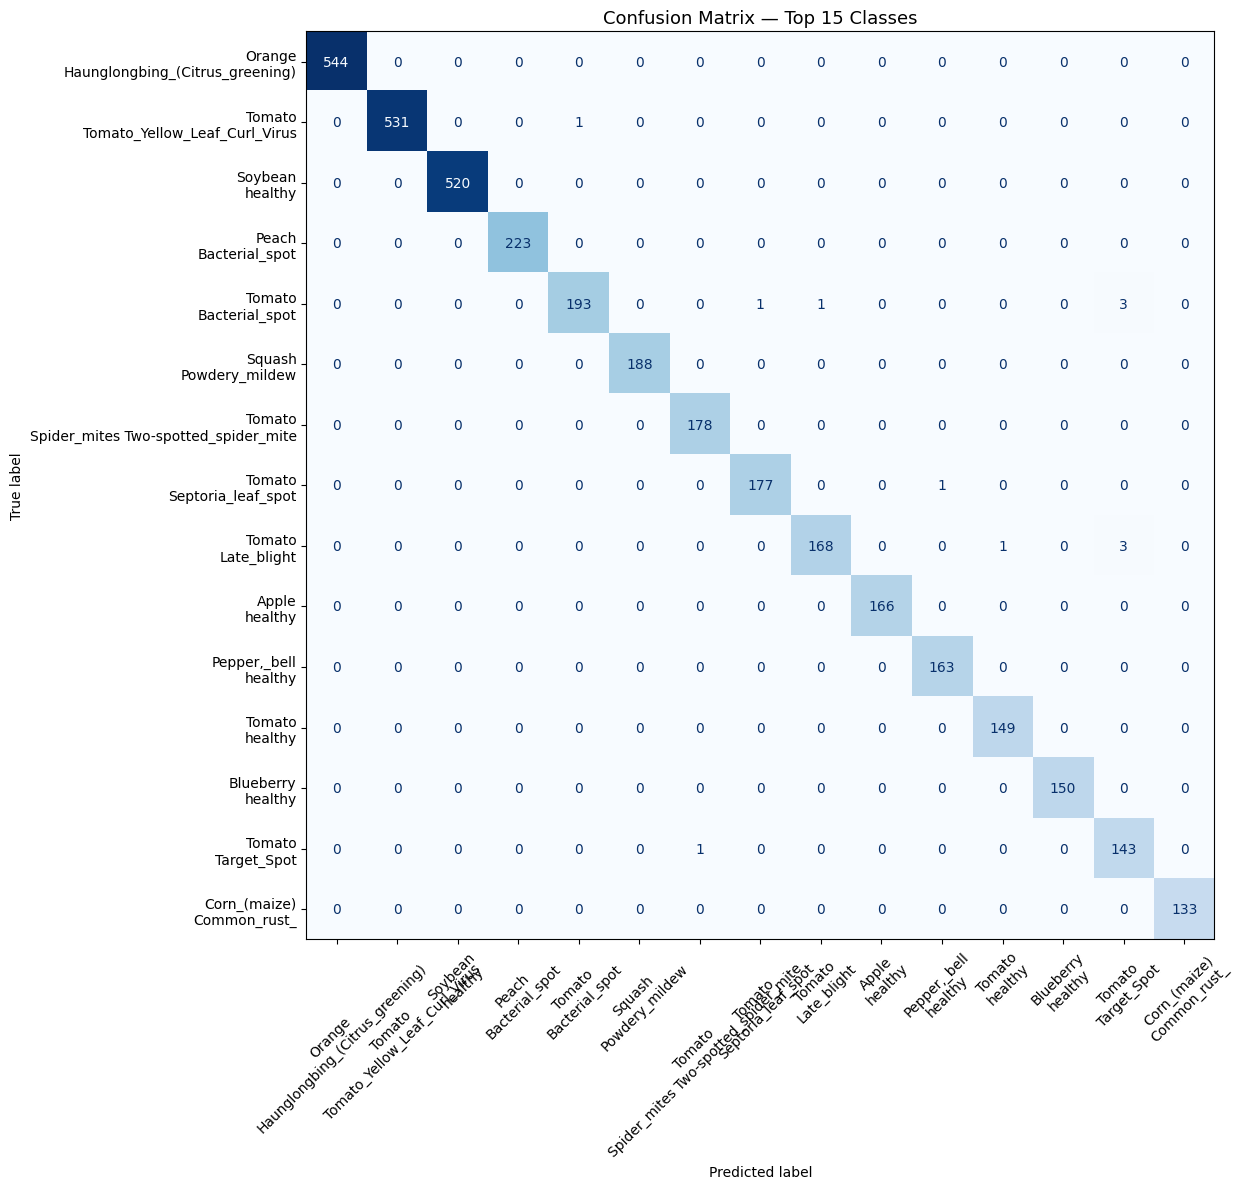

In [14]:
# ── Confusion matrix (top 15 classes) ────────────────────────
top_idx   = [i for i, _ in Counter(all_labels.tolist()).most_common(15)]
mask      = np.isin(all_labels, top_idx)
sub_names = [CLASS_NAMES[i].replace('___', '\n') for i in top_idx]
cm        = confusion_matrix(all_labels[mask], all_preds[mask], labels=top_idx)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay(cm, display_labels=sub_names).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45
)
ax.set_title('Confusion Matrix — Top 15 Classes', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

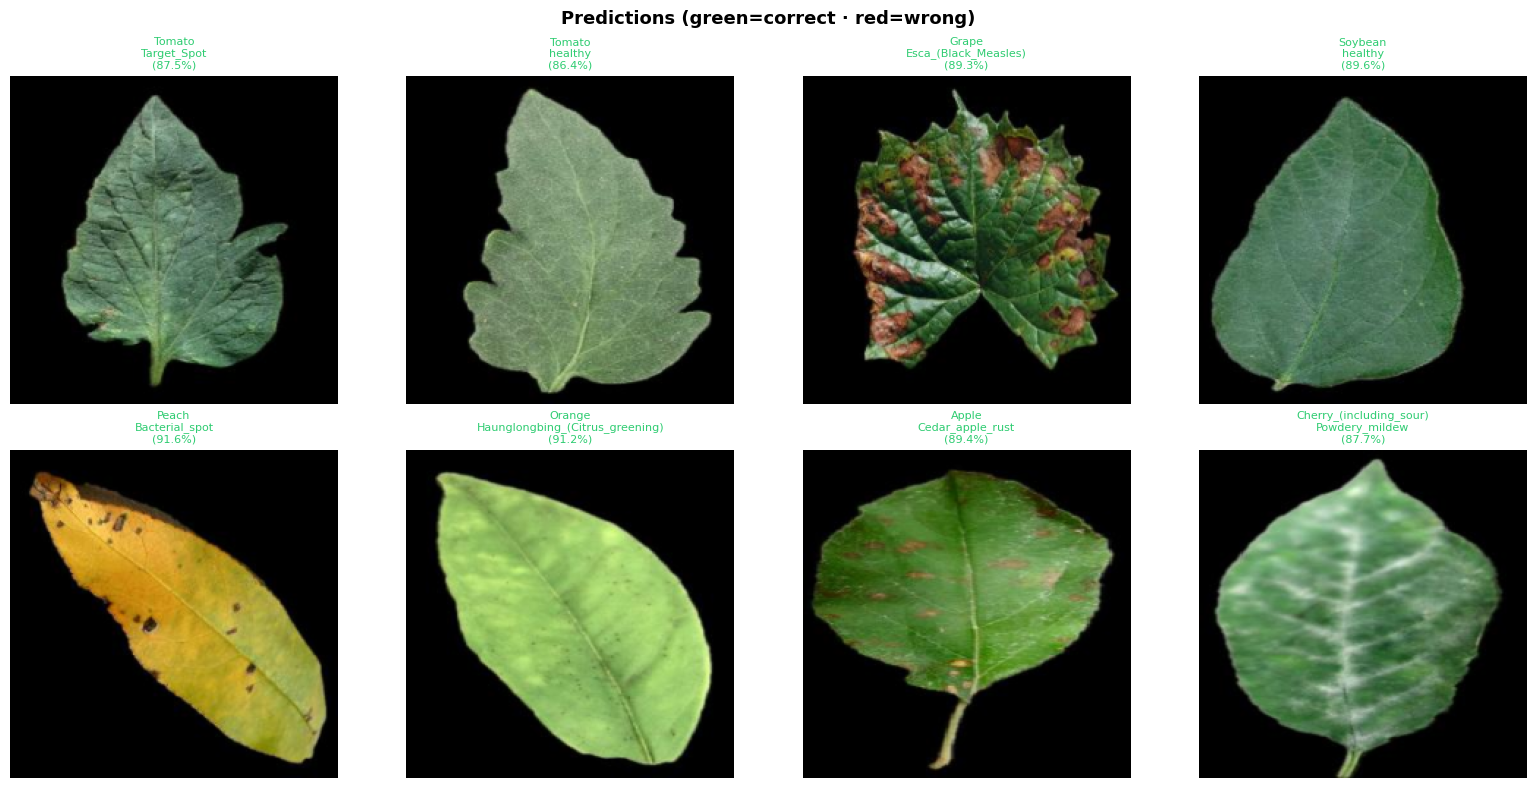

In [15]:
# ── Sample predictions ────────────────────────────────────────
model.eval()
imgs, lbls = next(iter(test_loader))
with torch.no_grad():
    probs = torch.softmax(model(imgs[:8].to(DEVICE)), dim=1)
    confs, preds = probs.max(1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = denorm(imgs[i]).permute(1,2,0).numpy()
    ax.imshow(img); ax.axis('off')
    correct = preds[i].item() == lbls[i].item()
    ax.set_title(
        f"{CLASS_NAMES[preds[i]].replace('___', chr(10))}\n({confs[i]:.1%})",
        fontsize=8, color='#2ecc71' if correct else '#e74c3c'
    )
plt.suptitle('Predictions (green=correct · red=wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=150)
plt.show()

## 7 — Grad-CAM

In [16]:
!pip install -q grad-cam==1.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


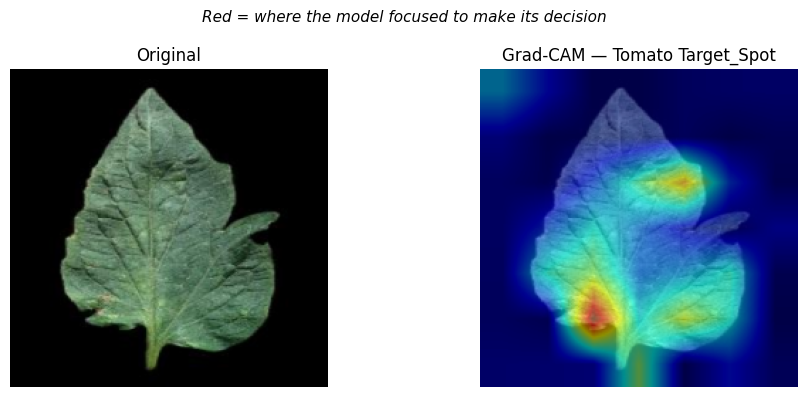

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.layer4[-1]]
sample_img, sample_label = test_ds[0]
input_tensor = sample_img.unsqueeze(0).to(DEVICE)

with GradCAM(model=model, target_layers=target_layers) as cam:
    grayscale = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(sample_label)]
    )[0]

rgb_img = denorm(sample_img).permute(1,2,0).numpy()
cam_img = show_cam_on_image(rgb_img, grayscale, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(rgb_img);  axes[0].axis('off'); axes[0].set_title('Original', fontsize=12)
axes[1].imshow(cam_img);  axes[1].axis('off')
axes[1].set_title(
    f"Grad-CAM — {CLASS_NAMES[sample_label].replace('___', ' ')}",
    fontsize=12
)
plt.suptitle('Red = where the model focused to make its decision',
             fontsize=11, style='italic')
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam.png', dpi=150)
plt.show()

## 8 — Save Model

In [18]:
SAVE_PATH = '/kaggle/working/disease_model.pt'

torch.save({
    'model_state_dict':  model.state_dict(),
    'class_names':       CLASS_NAMES,
    'num_classes':       NUM_CLASSES,
    'img_size':          IMG_SIZE,
    'mean':              MEAN,
    'std':               STD,
    'test_accuracy':     float(test_acc),
    'best_val_accuracy': float(best_val_acc),
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'Saved        : {SAVE_PATH}')
print(f'Size         : {size_mb:.1f} MB')
print(f'Test acc     : {test_acc:.2%}')
print(f'Best val acc : {best_val_acc:.2%}')
print()
print('Download: Notebook → Output tab → disease_model.pt')
print('Then place in: Project/models/disease_model.pt')

Saved        : /kaggle/working/disease_model.pt
Size         : 98.6 MB
Test acc     : 99.34%
Best val acc : 99.36%

Download: Notebook → Output tab → disease_model.pt
Then place in: Project/models/disease_model.pt


## 9 — Inference Function

In [19]:
REMEDY_MAP = {
    'Tomato___Early_blight': [
        'Apply Mancozeb or Chlorothalonil fungicide.',
        'Remove lower infected leaves immediately.',
        'Rotate crops each season.'
    ],
    'Tomato___Late_blight': [
        'Apply Metalaxyl or copper fungicide immediately.',
        'Remove and burn infected leaves.',
        'Act within 48 hours — spreads rapidly.'
    ],
    'Tomato___Bacterial_spot': [
        'Apply copper-based bactericide every 7–10 days.',
        'Avoid overhead irrigation.',
        'Use certified disease-free seeds.'
    ],
    'Tomato___Leaf_Mold': [
        'Improve ventilation.',
        'Apply Chlorothalonil fungicide.',
        'Water at base only.'
    ],
    'Tomato___Septoria_leaf_spot': [
        'Apply Mancozeb or copper fungicide.',
        'Remove infected lower leaves.',
        'Practice 2-year crop rotation.'
    ],
    'Tomato___Spider_mites Two-spotted_spider_mite': [
        'Apply Neem oil or insecticidal soap.',
        'Increase humidity.',
        'Keep plants well irrigated.'
    ],
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': [
        'Control whitefly population.',
        'Use reflective silver mulch.',
        'Remove and destroy infected plants.'
    ],
    'Tomato___Tomato_mosaic_virus': [
        'No cure — remove infected plants.',
        'Sanitize tools with 10% bleach.',
        'Plant resistant varieties next season.'
    ],
    'Potato___Early_Blight': [
        'Apply Mancozeb fungicide.',
        'Remove infected leaves.',
        'Ensure adequate potassium fertilization.'
    ],
    'Potato___Late_Blight': [
        'Apply Metalaxyl + Mancozeb immediately.',
        'Destroy infected tubers.',
        'URGENT: treat within 24 hours.'
    ],
    'Corn_(maize)___Common_rust_': [
        'Apply Mancozeb or Azoxystrobin.',
        'Plant rust-resistant varieties.',
        'Early planting avoids peak rust season.'
    ],
    'Apple___Apple_scab': [
        'Apply Captan fungicide at bud break.',
        'Rake and destroy fallen leaves.',
        'Prune for open canopy airflow.'
    ],
    'Grape___Black_rot': [
        'Apply Mancozeb fungicide.',
        'Remove all mummified berries.',
        'Prune for canopy air circulation.'
    ],
    'Orange___Haunglongbing_(Citrus_greening)': [
        'NO CURE — destroy infected trees immediately.',
        'Control Asian citrus psyllid.',
        'Report to local agriculture office.'
    ],
}

DEFAULT_REMEDY = [
    'Consult your local agricultural extension office.',
    'Remove and isolate infected material.',
    'Apply a broad-spectrum fungicide as precaution.',
]

def predict_disease(image_path: str, top_k: int = 3) -> dict:
    model.eval()
    img = Image.open(image_path).convert('RGB')

    tta_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])

    probs_list = []
    with torch.no_grad():
        # Original image
        tensor = val_tf(img).unsqueeze(0).to(DEVICE)
        probs_list.append(torch.softmax(model(tensor), dim=1)[0])
        # 4 augmented versions
        for _ in range(4):
            tensor = tta_tf(img).unsqueeze(0).to(DEVICE)
            probs_list.append(torch.softmax(model(tensor), dim=1)[0])

    avg_probs          = torch.stack(probs_list).mean(0)
    top_probs, top_idxs = avg_probs.topk(top_k)
    best               = CLASS_NAMES[top_idxs[0]]

    return {
        'disease':    best,
        'confidence': f'{top_probs[0]:.2%}',
        'remedies':   REMEDY_MAP.get(best, DEFAULT_REMEDY),
        'top_k': [
            {'disease': CLASS_NAMES[i], 'confidence': f'{p:.2%}'}
            for p, i in zip(top_probs.cpu(), top_idxs.cpu())
        ]
    }

# def predict_disease(image_path: str, top_k: int = 3) -> dict:
#     model.eval()
#     img    = Image.open(image_path).convert('RGB')
#     tensor = val_tf(img).unsqueeze(0).to(DEVICE)
#     with torch.no_grad():
#         probs = torch.softmax(model(tensor), dim=1)[0]
#     top_probs, top_idxs = probs.topk(top_k)
#     best = CLASS_NAMES[top_idxs[0]]
#     return {
#         'disease':    best,
#         'confidence': f'{top_probs[0]:.2%}',
#         'remedies':   REMEDY_MAP.get(best, DEFAULT_REMEDY),
#         'top_k': [
#             {'disease': CLASS_NAMES[i], 'confidence': f'{p:.2%}'}
#             for p, i in zip(top_probs.cpu(), top_idxs.cpu())
#         ]
#     }


# ── Test on a random image ────────────────────────────────────
import random as rnd
sample_path = rnd.choice(list(DATA_DIR.rglob('*.jpg')))
result = predict_disease(str(sample_path))

print('─── Disease Prediction Result ───')
print(f"Disease    : {result['disease']}")
print(f"Confidence : {result['confidence']}")
print('Remedies   :')
for i, r in enumerate(result['remedies'], 1):
    print(f'  {i}. {r}')
print('\nTop-3:')
for p in result['top_k']:
    print(f"  {p['disease']:45s} {p['confidence']}")

─── Disease Prediction Result ───
Disease    : Apple___healthy
Confidence : 89.93%
Remedies   :
  1. Consult your local agricultural extension office.
  2. Remove and isolate infected material.
  3. Apply a broad-spectrum fungicide as precaution.

Top-3:
  Apple___healthy                               89.93%
  Corn_(maize)___Common_rust_                   0.48%
  Pepper,_bell___healthy                        0.40%


---
## Done!

| Output file | Location | Next step |
|---|---|---|
| `disease_model.pt` | Output tab | Download → `Project/models/` |
| `training_curves.png` | Output tab | Use in presentation |
| `confusion_matrix.png` | Output tab | Use in presentation |
| `gradcam.png` | Output tab | Use in presentation |

Load `disease_model.pt` in your **FastAPI backend** to serve predictions.